# 06 — Rolling-origin backtesting

**Goal.** Compare three forecasters on the hourly load series under **8 rolling-origin folds**.

```
rolling_origin_eval(model_fn, series, h, n_splits, step,
                    window="sliding", window_size=..., min_train_size=...)
```

- **Refits** `model_fn` from scratch on every fold (expanding *or* sliding window).
- **Forecasts** `h` hours ahead from each cut.
- Returns a **per-fold** DataFrame and an **aggregate** summary (mean / median / std across folds).

**Models compared**

- **Seasonal naïve (lag-24):** $\hat{y}_{T+i} = y_{T+i-24}$.
- **ETS (Holt–Winters):** additive trend + additive seasonality, `seasonal_periods = 24`.
- **SARIMA(1,1,1)(1,0,1,24):** order reused from notebook 05 so we never re-run `auto_arima` inside the loop.

**Backtest setup**

- Horizon: $h = 24$ hours.
- Folds: $n_\text{splits} = 8$, $\text{step} = h$ → non-overlapping test windows covering the last $8 \times 24 = 192$ hours.
- Sliding training window of **60 days = 1440 hours** for every model. Same slice per fold makes the comparison fair *and* keeps SARIMA refits tractable.

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tools.sm_exceptions import ConvergenceWarning # Many statistical models (like ARIMA, SARIMA, or some optimization routines in statsmodels) are fitted using iterative algorithms. A ConvergenceWarning is issued when such an iterative algorithm fails to converge to a solution within the specified number of iterations or a given tolerance. This doesn't always mean the model fit is bad, but it can indicate that the optimization process struggled to find a stable solution.
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX # SARIMAX extends this by allowing you to include additional independent variables (exogenous variables) in your model. These exogenous variables can help improve the forecast accuracy by accounting for other factors that might influence your time series.

_SRC = Path.cwd().resolve() / "src"
if _SRC.is_dir() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from utils import (
    coverage,
    load_hourly_load_series,
    mae,
    pinball,
    plot_fold_point_forecasts_overlay,
    plot_per_fold_mae_rmse,
    plot_sarima_prediction_interval_fold,
    rolling_origin_eval,
)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
TZ = "Europe/Berlin"

y = load_hourly_load_series(tz=TZ)

print("Rows:", len(y), "|", y.index.min(), "->", y.index.max())

Rows: 26304 | 2023-01-01 00:00:00+01:00 -> 2025-12-31 23:00:00+01:00


In [ ]:
# Point metrics (mae, rmse, mape, smape, score) and rolling_origin_eval live in `src/utils.py`.

## `rolling_origin_eval`

Folds are indexed from the **most recent** backwards. For fold `k = 0, 1, …, n_splits-1`:

- `test_end   = n - k * step` `k`: This is the current fold index, starting from 0 up to n_splits - 1. The folds are indexed backwards from the most recent data. `step` Inline code: This is the number of observations between the start of consecutive test windows. In your notebook, step = H = 24, meaning each test window immediately follows the previous one without overlap.
- `test_start = test_end - h` This calculates the start index of the current fold's test set. The test set always has a length of h (the forecast horizon).
- `train_end  = test_start`

Training slice:

- `window="expanding"` → `series[:train_end]` (must satisfy `min_train_size`). When window is set to "expanding", the training data starts from the very beginning of the series (index 0) and extends up to train_end.
- `window="sliding"`   → `series[train_end - window_size : train_end]`. With "sliding", the training data has a fixed length (window_size). It ends at train_end (just before the test set) and starts window_size observations before that.

The only model-specific knob is the callable `model_fn(train, h) -> np.ndarray` of length `h`, which is responsible for the full **refit + h-step forecast** on each fold.

It automates the process of repeatedly training (refitting) a model on a historical dataset and then generating forecasts for a subsequent, unseen period. * It collects performance metrics for each "fold" (each iteration of training and forecasting) and then aggregates these metrics to give an overall picture of the model's reliability.

In [ ]:
# rolling_origin_eval is imported from utils.


## Model adapters

Each adapter conforms to the contract `(train, h) -> np.ndarray` and **refits from scratch** on every fold. SARIMA reuses the order chosen by `auto_arima` in notebook 05 so the loop never re-runs the order search.

In [ ]:
SEASONAL_PERIODS = 24
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 0, 1, 24)
#  the SARIMA model uses a pre-determined fixed order (SARIMA_ORDER and SARIMA_SEASONAL_ORDER). This avoids repeatedly running the auto_arima search within each of the 8 folds


def seasonal_naive_fn(train: pd.Series, h: int) -> np.ndarray:
    """ŷ_{T+i} = y_{T+i-24}, recycled if h > 24."""
    last_cycle = train.values[-SEASONAL_PERIODS:]
    reps = int(np.ceil(h / SEASONAL_PERIODS)) # This calculates how many times the last_cycle needs to be repeated to cover the forecast horizon
    return np.tile(last_cycle, reps)[:h] #  This NumPy function takes last_cycle and repeats it reps times


def ets_fn(train: pd.Series, h: int) -> np.ndarray:
    fitted = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=SEASONAL_PERIODS,
        initialization_method="estimated",
    ).fit(optimized=True) # optimized=True (which is the default behavior in recent statsmodels versions if not specified) means that the fitting process will try to find the optimal values for the smoothing parameters (like alpha, beta, gamma in ETS) by minimizing an error function (e.g., sum of squared errors). It uses numerical optimization techniques to search for the best combination of these parameters.
    return np.asarray(fitted.forecast(h), dtype=float)


def sarima_fn(train: pd.Series, h: int) -> np.ndarray:
    res = SARIMAX(
        train,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, # This suppresses the verbose output during the optimization process.
          method="lbfgs",  # This specifies the optimization algorithm to use. L-BFGS is a popular algorithm for numerical optimization.
          maxiter=200) # This sets the maximum number of iterations the optimizer will perform to find the model parameters.
    return np.asarray(res.forecast(h), dtype=float)

## Run 8 folds × {Seasonal naive, ETS, SARIMA}

Same sliding 60-day training window for every model so the comparison is apples-to-apples.

In [ ]:
H = 24
N_SPLITS = 8
STEP = 24
WINDOW = "sliding"
WINDOW_SIZE = 60 * 24  # 60 days of hourly history per fit

if len(y) < WINDOW_SIZE + N_SPLITS * STEP:
    raise ValueError("Series too short for the chosen window/folds.")

print("=== Seasonal naive (lag-24) ===")
sn_per_fold, sn_agg, sn_fc = rolling_origin_eval(
    seasonal_naive_fn, y,
    h=H, n_splits=N_SPLITS, step=STEP,
    window=WINDOW, window_size=WINDOW_SIZE,
)

print("\n=== ETS (Holt–Winters, add+add, m=24) ===")
ets_per_fold, ets_agg, ets_fc = rolling_origin_eval(
    ets_fn, y,
    h=H, n_splits=N_SPLITS, step=STEP,
    window=WINDOW, window_size=WINDOW_SIZE,
)

print(f"\n=== SARIMA{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER} ===")
sa_per_fold, sa_agg, sa_fc = rolling_origin_eval(
    sarima_fn, y,
    h=H, n_splits=N_SPLITS, step=STEP,
    window=WINDOW, window_size=WINDOW_SIZE,
)

=== Seasonal naive (lag-24) ===
  fold  0: cut=2025-12-30 23:00:00+01:00  train_len= 1440 | MAE=2843.89  RMSE=3287.72  MAPE=5.34%
  fold  1: cut=2025-12-29 23:00:00+01:00  train_len= 1440 | MAE=789.94  RMSE=962.15  MAPE=1.43%
  fold  2: cut=2025-12-28 23:00:00+01:00  train_len= 1440 | MAE=5059.63  RMSE=5676.43  MAPE=8.88%
  fold  3: cut=2025-12-27 23:00:00+01:00  train_len= 1440 | MAE=2321.99  RMSE=2738.68  MAPE=4.49%
  fold  4: cut=2025-12-26 23:00:00+01:00  train_len= 1440 | MAE=3669.60  RMSE=4360.56  MAPE=6.62%
  fold  5: cut=2025-12-25 23:00:00+01:00  train_len= 1440 | MAE=604.53  RMSE=654.40  MAPE=1.26%
  fold  6: cut=2025-12-24 23:00:00+01:00  train_len= 1440 | MAE=2963.66  RMSE=3666.86  MAPE=6.09%
  fold  7: cut=2025-12-23 23:00:00+01:00  train_len= 1440 | MAE=4948.74  RMSE=5648.51  MAPE=9.25%

=== ETS (Holt–Winters, add+add, m=24) ===


  fold  0: cut=2025-12-30 23:00:00+01:00  train_len= 1440 | MAE=21990.83  RMSE=24753.89  MAPE=40.89%


  fold  1: cut=2025-12-29 23:00:00+01:00  train_len= 1440 | MAE=10911.14  RMSE=12087.80  MAPE=19.19%


  fold  2: cut=2025-12-28 23:00:00+01:00  train_len= 1440 | MAE=17668.68  RMSE=19995.13  MAPE=30.81%


  fold  3: cut=2025-12-27 23:00:00+01:00  train_len= 1440 | MAE=21477.79  RMSE=23690.40  MAPE=41.26%


...

  fold  3: cut=2025-12-27 23:00:00+01:00  train_len= 1440 | MAE=3901.58  RMSE=4600.90  MAPE=7.78%


  fold  4: cut=2025-12-26 23:00:00+01:00  train_len= 1440 | MAE=1386.36  RMSE=1789.42  MAPE=2.56%


  fold  5: cut=2025-12-25 23:00:00+01:00  train_len= 1440 | MAE=4866.88  RMSE=5668.89  MAPE=9.79%


  fold  6: cut=2025-12-24 23:00:00+01:00  train_len= 1440 | MAE=5574.63  RMSE=6568.55  MAPE=11.32%


  fold  7: cut=2025-12-23 23:00:00+01:00  train_len= 1440 | MAE=4330.50  RMSE=4878.84  MAPE=8.22%


## Per-fold and aggregate results

In [ ]:
metric_cols = ["MAE", "RMSE", "MAPE_%", "sMAPE_%"]

per_fold_all = pd.concat(
    {
        "Seasonal naive": sn_per_fold.set_index("fold")[metric_cols],
        "ETS":            ets_per_fold.set_index("fold")[metric_cols],
        "SARIMA":         sa_per_fold.set_index("fold")[metric_cols],
    },
    axis=1,
)

print("Per-fold metrics (fold 0 is the most recent 24-hour window):")
display(per_fold_all)

aggregate_mean = pd.concat(
    {
        "Seasonal naive": sn_agg["mean"],
        "ETS":            ets_agg["mean"],
        "SARIMA":         sa_agg["mean"],
    },
    axis=1,
).T
aggregate_mean.index.name = "model"

aggregate_std = pd.concat(
    {
        "Seasonal naive": sn_agg["std"],
        "ETS":            ets_agg["std"],
        "SARIMA":         sa_agg["std"],
    },
    axis=1,
).T
aggregate_std.index.name = "model"

print("\nMean across folds:")
display(aggregate_mean)

print("\nStd. dev. across folds:")
display(aggregate_std)

Per-fold metrics (fold 0 is the most recent 24-hour window):


Seasonal naive                                   ETS                      \
                MAE       RMSE MAPE_% sMAPE_%         MAE        RMSE  MAPE_%   
fold                                                                            
0        2,843.8902 3,287.7169 5.3394  5.1768 21,990.8319 24,753.8932 40.8882   
1          789.9440   962.1454 1.4257  1.4171 10,911.1447 12,087.8016 19.1908   
2        5,059.6331 5,676.4345 8.8820  9.3916 17,668.6842 19,995.1289 30.8140   
3        2,321.9940 2,738.6755 4.4923  4.3825 21,477.7862 23,690.4017 41.2560   
4        3,669.6008 4,360.5578 6.6157  6.9207 20,611.3293 23,102.4255 38.0813   
5          604.5322   654.3957 1.2632  1.2660 30,959.8512 34,496.4092 62.0755   
6        2,963.6603 3,666.8592 6.0862  5.8201 28,301.4638 31,283.3427 56.7682   
7        4,948.7378 5,648.5086 9.2538  8.7405  2,697.7135  3,589.7302  5.2879   

                 SARIMA                             
     sMAPE_%        MAE       RMSE  MAPE_% sMAPE_%  
fold                                                
0    32.6123 3,082.9361 3,559.2984  5.7651  5.5511  
1    17.2291   829.6598 1,021.3665  1.5051  1.5140  
2    25.8870   906.5908 1,281.9522  1.5356  1.5558  
3    33.2641 3,901.5815 4,600.9009  7.7799  7.3846  
4    30.9546 1,386.3649 1,789.4161  2.5579  2.5841  
5    45.2596 4,866.8787 5,668.8866  9.7896  9.1830  
6    42.5072 5,574.6339 6,568.5525 11.3195 10.4930  
7     5.1060 4,330.4957 4,878.8405  8.2156  7.8133


Mean across folds:


,MAE,RMSE,MAPE_%,sMAPE_%
model,,,,
Seasonal naive,"2,900.2490","3,374.4117",5.4198,5.3894
ETS,"19,327.3506","21,624.8916",36.7952,29.1025
SARIMA,"3,109.8927","3,671.1517",6.0585,5.7599



Std. dev. across folds:


,MAE,RMSE,MAPE_%,sMAPE_%
model,,,,
Seasonal naive,"1,561.9070","1,773.3453",2.7986,2.8200
ETS,"8,509.8870","9,314.5115",17.3735,12.2523
SARIMA,"1,742.9812","1,968.2447",3.5837,3.2941


## Per-fold MAE / RMSE by model

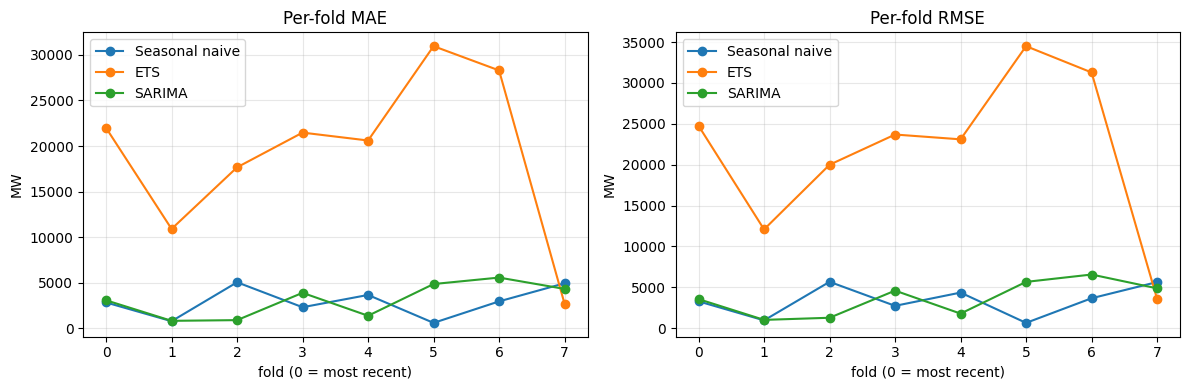

In [ ]:
per_fold_mae = pd.DataFrame(
    {
        "Seasonal naive": sn_per_fold["MAE"].values,
        "ETS":            ets_per_fold["MAE"].values,
        "SARIMA":         sa_per_fold["MAE"].values,
    },
    index=sn_per_fold["fold"],
)

per_fold_rmse = pd.DataFrame(
    {
        "Seasonal naive": sn_per_fold["RMSE"].values,
        "ETS":            ets_per_fold["RMSE"].values,
        "SARIMA":         sa_per_fold["RMSE"].values,
    },
    index=sn_per_fold["fold"],
)

plot_per_fold_mae_rmse(per_fold_mae, per_fold_rmse)
plt.show()


## Forecast overlay — most recent fold

Sanity check that all three models are pointing in the right direction on the latest fold.

## Probabilistic evaluation — does the 95% PI actually contain the truth 95% of the time?

A point forecast only tells half the story. Two simple checks:

- **Prediction-interval coverage.** Build a $1 - \alpha$ interval $[\hat{q}_{\alpha/2},\, \hat{q}_{1-\alpha/2}]$ and measure the empirical share of test points that fall inside. A well-calibrated 95% PI should cover ≈ 0.95 of the truth; systematically lower means the model is **overconfident**, higher means it's too wide.
- **Pinball loss** (a.k.a. quantile loss) at quantile $q$:

$$\rho_q(y, \hat{q}) \;=\; \begin{cases} q\,(y - \hat{q}) & \text{if } y \ge \hat{q}\\ (1 - q)\,(\hat{q} - y) & \text{if } y < \hat{q} \end{cases} \;=\; \max\!\big(q\,(y - \hat{q}),\; (q-1)\,(y - \hat{q})\big).$$

Lower is better. At $q = 0.5$ pinball loss equals **MAE / 2**; at $q = 0.1$ and $q = 0.9$ it rewards a tight 80% interval that still covers the right share of mass.

We refit SARIMA(1,1,1)(1,0,1,24) per fold and pull its Gaussian prediction intervals **by hand** through `SARIMAX.get_forecast().conf_int(alpha=…)`. Two intervals per fold:

- $\alpha = 0.05$ → 95% PI ⇒ the 0.025 and 0.975 quantiles (used for the coverage check).
- $\alpha = 0.20$ → 80% PI ⇒ the **0.1 and 0.9 quantiles** (used directly for pinball loss).

The median ($q = 0.5$) is the predicted mean — under SARIMAX's Gaussian innovations assumption mean ≡ median.

In [ ]:
SARIMA_QUANTILES = [0.025, 0.1, 0.5, 0.9, 0.975]


def sarima_quantile_backtest(
    series: pd.Series,
    h: int,
    n_splits: int,
    step: int,
    window_size: int,
) -> tuple[dict[float, dict[int, pd.Series]], dict[int, pd.Series]]:
    """Refit SARIMA per fold; collect quantile forecasts at 0.025 / 0.1 / 0.5 / 0.9 / 0.975."""
    n = len(series)
    quantiles: dict[float, dict[int, pd.Series]] = {q: {} for q in SARIMA_QUANTILES}
    actuals: dict[int, pd.Series] = {}

    for k in range(n_splits):
        test_end = n - k * step
        test_start = test_end - h
        train = series.iloc[test_start - window_size : test_start]
        test = series.iloc[test_start:test_end]

        res = SARIMAX(
            train,
            order=SARIMA_ORDER,
            seasonal_order=SARIMA_SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, method="lbfgs", maxiter=200)

        fc = res.get_forecast(h)
        mean = np.asarray(fc.predicted_mean, dtype=float)
        ci_95 = fc.conf_int(alpha=0.05).values
        ci_80 = fc.conf_int(alpha=0.20).values

        idx = test.index
        quantiles[0.025][k] = pd.Series(ci_95[:, 0], index=idx)
        quantiles[0.975][k] = pd.Series(ci_95[:, 1], index=idx)
        quantiles[0.1][k]   = pd.Series(ci_80[:, 0], index=idx)
        quantiles[0.9][k]   = pd.Series(ci_80[:, 1], index=idx)
        quantiles[0.5][k]   = pd.Series(mean,        index=idx)
        actuals[k] = test

        print(f"  fold {k:>2}: cut={train.index[-1]} | SARIMA refit + intervals")

    return quantiles, actuals


sa_quantiles, sa_actuals = sarima_quantile_backtest(
    y,
    h=H,
    n_splits=N_SPLITS,
    step=STEP,
    window_size=WINDOW_SIZE,
)

  fold  0: cut=2025-12-30 23:00:00+01:00 | SARIMA refit + intervals


  fold  1: cut=2025-12-29 23:00:00+01:00 | SARIMA refit + intervals


  fold  2: cut=2025-12-28 23:00:00+01:00 | SARIMA refit + intervals


  fold  3: cut=2025-12-27 23:00:00+01:00 | SARIMA refit + intervals


  fold  4: cut=2025-12-26 23:00:00+01:00 | SARIMA refit + intervals


  fold  5: cut=2025-12-25 23:00:00+01:00 | SARIMA refit + intervals


  fold  6: cut=2025-12-24 23:00:00+01:00 | SARIMA refit + intervals


  fold  7: cut=2025-12-23 23:00:00+01:00 | SARIMA refit + intervals


### 95% (and 80%) PI coverage by fold

Coverage = share of the 24 test hours where the truth falls inside the interval. Also report mean PI **width** (MW): wider intervals are easier to cover, so coverage and width should be read together.

In [ ]:

coverage_rows = []
for k in range(N_SPLITS):
    y_true = sa_actuals[k].values
    lo95 = sa_quantiles[0.025][k].values
    hi95 = sa_quantiles[0.975][k].values
    lo80 = sa_quantiles[0.1][k].values
    hi80 = sa_quantiles[0.9][k].values
    coverage_rows.append(
        {
            "fold": k,
            "cut_time": sa_actuals[k].index[0] - pd.Timedelta(hours=1),
            "coverage_95%": coverage(y_true, lo95, hi95),
            "coverage_80%": coverage(y_true, lo80, hi80),
            "mean_width_95%": float(np.mean(hi95 - lo95)),
            "mean_width_80%": float(np.mean(hi80 - lo80)),
        }
    )

coverage_df = pd.DataFrame(coverage_rows)
print("Per-fold coverage (nominal 95% and 80%):")
display(coverage_df)

mean_cov95 = coverage_df["coverage_95%"].mean()
mean_cov80 = coverage_df["coverage_80%"].mean()
print(
    "\nAggregate coverage across folds:\n"
    f"  95% PI empirical coverage = {mean_cov95:.3f}   (target 0.95)\n"
    f"  80% PI empirical coverage = {mean_cov80:.3f}   (target 0.80)\n"
    f"  mean 95% PI width = {coverage_df['mean_width_95%'].mean():,.0f} MW\n"
    f"  mean 80% PI width = {coverage_df['mean_width_80%'].mean():,.0f} MW"
)

Per-fold coverage (nominal 95% and 80%):


,fold,cut_time,coverage_95%,coverage_80%,mean_width_95%,mean_width_80%
0,0,2025-12-30 23:00:00+01:00,1.0000,1.0000,"23,711.3209","15,503.9994"
1,1,2025-12-29 23:00:00+01:00,1.0000,1.0000,"23,560.7194","15,405.5264"
2,2,2025-12-28 23:00:00+01:00,1.0000,1.0000,"23,316.1963","15,245.6413"
3,3,2025-12-27 23:00:00+01:00,1.0000,0.8750,"23,407.3267","15,305.2283"
4,4,2025-12-26 23:00:00+01:00,1.0000,1.0000,"23,750.4535","15,529.5868"
5,5,2025-12-25 23:00:00+01:00,1.0000,0.8333,"23,298.5530","15,234.1050"
6,6,2025-12-24 23:00:00+01:00,0.9167,0.7917,"23,923.3179","15,642.6168"
7,7,2025-12-23 23:00:00+01:00,1.0000,0.8750,"23,398.3399","15,299.3521"



Aggregate coverage across folds:
  95% PI empirical coverage = 0.990   (target 0.95)
  80% PI empirical coverage = 0.922   (target 0.80)
  mean 95% PI width = 23,546 MW
  mean 80% PI width = 15,396 MW


### Pinball loss at $q \in \{0.1, 0.5, 0.9\}$ — hand-rolled

No scoring library imports. The function below implements the formula directly.

In [ ]:

PINBALL_LEVELS = (0.1, 0.5, 0.9)

pinball_rows = []
for k in range(N_SPLITS):
    y_true = sa_actuals[k].values
    row = {"fold": k}
    for q in PINBALL_LEVELS:
        row[f"pinball_q{q}"] = pinball(y_true, sa_quantiles[q][k].values, q)
    pinball_rows.append(row)

pinball_df = pd.DataFrame(pinball_rows)
print("Per-fold pinball loss in MW (lower is better):")
display(pinball_df)

mean_pinball = pinball_df.drop(columns=["fold"]).mean()
print("\nMean pinball loss across folds:")
display(mean_pinball.to_frame("mean_MW"))

mae_median = np.mean(
    [mae(sa_actuals[k].values, sa_quantiles[0.5][k].values) for k in range(N_SPLITS)]
)
print(
    f"\nSanity check: mean pinball@0.5 = {mean_pinball['pinball_q0.5']:,.2f} MW "
    f"≈ MAE(median) / 2 = {mae_median / 2:,.2f} MW"
)

Per-fold pinball loss in MW (lower is better):


,fold,pinball_q0.1,pinball_q0.5,pinball_q0.9
0,0,470.9348,"1,541.4681","1,079.4651"
1,1,814.4978,414.8299,726.0549
2,2,830.6064,453.2954,693.9578
3,3,424.1276,"1,950.7907","1,148.4519"
4,4,832.8603,693.1824,720.0984
5,5,509.1643,"2,433.4394","1,246.1195"
6,6,786.1199,"2,787.3170","1,336.6912"
7,7,439.4738,"2,165.2478","1,198.0172"



Mean pinball loss across folds:


,mean_MW
pinball_q0.1,638.4731
pinball_q0.5,"1,554.9463"
pinball_q0.9,"1,018.6070"



Sanity check: mean pinball@0.5 = 1,554.95 MW ≈ MAE(median) / 2 = 1,554.95 MW


### Visualizing one fold: SARIMA median + 80% and 95% intervals

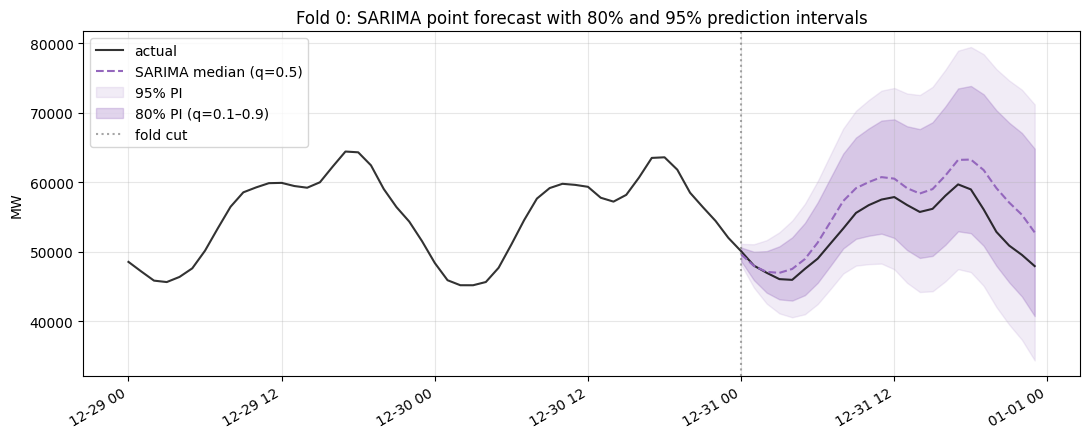

In [ ]:
fold_to_plot = 0
test = sa_actuals[fold_to_plot]
median = sa_quantiles[0.5][fold_to_plot]
lo95 = sa_quantiles[0.025][fold_to_plot]
hi95 = sa_quantiles[0.975][fold_to_plot]
lo80 = sa_quantiles[0.1][fold_to_plot]
hi80 = sa_quantiles[0.9][fold_to_plot]

plot_sarima_prediction_interval_fold(
    y,
    test=test,
    median=median,
    lo95=lo95,
    hi95=hi95,
    lo80=lo80,
    hi80=hi80,
    fold=fold_to_plot,
    ctx_hours=48,
)
plt.show()


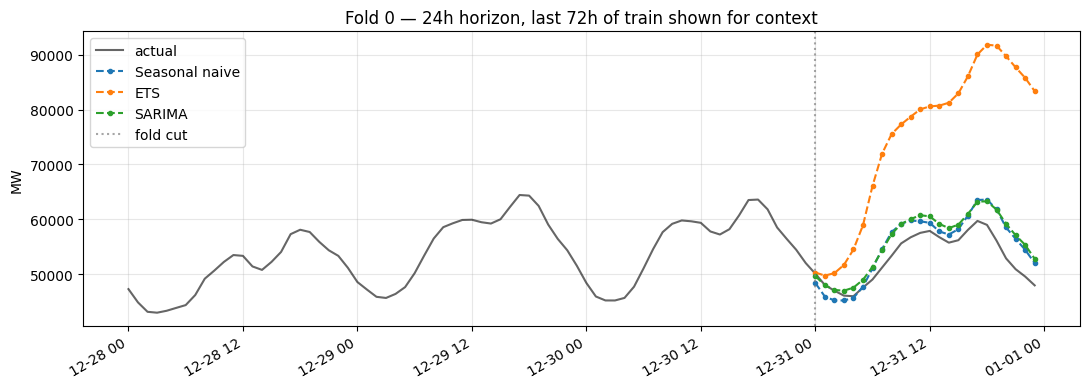

In [ ]:
fold_to_plot = 0
plot_fold_point_forecasts_overlay(
    y,
    seasonal_naive=sn_fc[fold_to_plot],
    ets=ets_fc[fold_to_plot],
    sarima=sa_fc[fold_to_plot],
    fold=fold_to_plot,
    horizon_h=H,
    ctx_hours=72,
)
plt.show()
